## Phase 1: Setup

In [ ]:
!pip install -q datasets huggingface_hub pandas openai

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from datasets import load_dataset

ds = load_dataset("wanglab/variant_effect_coding")
print(ds)

README.md:   0%|          | 0.00/1.96k [00:00<?, ?B/s]

train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 99.3MB            

train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.05MB            

test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/48850 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1233 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['ID', 'question', 'answer', 'reference_sequence', 'variant_sequence'],
        num_rows: 48850
    })
    test: Dataset({
        features: ['ID', 'question', 'answer', 'reference_sequence', 'variant_sequence'],
        num_rows: 1233
    })
})


In [ ]:
train_data = ds['train']
test_df = ds['test'].to_pandas()

# Extract clean binary label from the 'answer' column (format: "Label; Disease")
test_df['true_label'] = test_df['answer'].apply(lambda x: x.split(';')[0].strip())

print(test_df['true_label'].value_counts())
print("Total test rows:", len(test_df))

true_label
Pathogenic    676
Benign        557
Name: count, dtype: int64
Total test rows: 1233


In [ ]:
import pandas as pd

# Build a small, balanced sample (15 Pathogenic + 15 Benign) to work with
sample_df = pd.concat([
    test_df[test_df['true_label'] == 'Pathogenic'].sample(15, random_state=42),
    test_df[test_df['true_label'] == 'Benign'].sample(15, random_state=42)
]).reset_index(drop=True)

print(sample_df[['ID', 'question', 'true_label']])

                 ID                                           question  \
0    Task1_test_641  This mutation is located in gene GPIHBP1 (glyc...   
1    Task1_test_302  A variant on Chromosome 8 in gene CYP7B1 (cyto...   
2    Task1_test_369  This mutation occurs in GDAP1 (ganglioside ind...   
3    Task1_test_493  This is a variant in RRM2B (ribonucleotide red...   
4    Task1_test_579  This sequence variant lies in DNAAF11 (dynein ...   
5     Task1_test_54  The following genetic variant occurs in LPL (l...   
6    Task1_test_645  A variant on Chromosome 8 in gene PLEC (plecti...   
7    Task1_test_257  Given this variant in gene RPS20 (ribosomal pr...   
8    Task1_test_663  A variant found in Chromosome 8 affects SLC52A...   
9    Task1_test_478  This alteration in GDF6 (growth differentiatio...   
10    Task1_test_55  This variant lies on Chromosome 8 and affects ...   
11   Task1_test_639  Given this context: Chromosome 8, gene GPIHBP1...   
12   Task1_test_481  This gene mutatio

## Phase 2 & 3: Prompt Design + Cloud Inference

**Model:** `Qwen/Qwen3-8B:featherless-ai` — chosen because it has native "thinking mode",
returning reasoning in `message.reasoning` and the final verdict in `message.content`
(unlike Qwen2.5-7B-Instruct, which does not reliably produce chain-of-thought reasoning).

In [ ]:
from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=userdata.get('colab-bioreason')
)

In [ ]:
import time

def classify_variant(question_text, max_retries=3):
    """Send one variant question to Qwen3-8B, return reasoning + content, with retry on failure."""
    prompt = f"""{question_text}

After your analysis, you MUST end with exactly this line and nothing else after it:
Final Answer: [Pathogenic|Benign]"""

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model="Qwen/Qwen3-8B:featherless-ai",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.6,
                max_tokens=1500
            )
            message = response.choices[0].message
            return {
                "reasoning": message.reasoning,
                "content": message.content,
                "error": None
            }
        except Exception as e:
            wait_time = 2 ** attempt  # exponential backoff: 1s, 2s, 4s
            print(f"Attempt {attempt+1} failed: {e}. Retrying in {wait_time}s...")
            time.sleep(wait_time)

    return {"reasoning": None, "content": None, "error": "Failed after retries"}

# Quick test on one row to confirm the function works
test_result = classify_variant(sample_df.iloc[0]['question'])
print(test_result)

{'reasoning': '\nOkay, I need to figure out if the mutation in the GPIHBP1 gene on Chromosome 8 is associated with a disease or is a benign polymorphism. Let me start by recalling what GPIHBP1 does. From what I remember, GPIHBP1 is involved in lipid metabolism, specifically in transporting chylomicrons and very low-density lipoproteins (VLDL) from the lymphatic system to the bloodstream. It\'s a glycosylphosphatidylinositol-anchored protein, which means it\'s attached to the cell membrane.\n\nNow, mutations in this gene could potentially affect its function. I should check if there are any known diseases linked to GPIHBP1. I recall that mutations in GPIHBP1 have been associated with familial combined hyperlipidemia, which is a condition that increases the risk of cardiovascular disease. But wait, I need to be careful here. Let me think if there\'s a specific mutation that\'s well-documented. For example, some studies have linked certain variants in GPIHBP1 to lipid abnormalities. Howev

## Phase 3: Batch Inference with Incremental Saving

Results are saved to disk one row at a time (`results.jsonl`), so a rate-limit
error, credit depletion, or runtime disconnect never loses completed work.
Re-running this cell will skip rows already saved.

In [ ]:
import json
import os

output_file = "/content/results.jsonl"  # jsonl = one JSON object per line

if not os.path.exists(output_file):
    open(output_file, 'w').close()

# Find which IDs are already completed, so re-runs don't repeat them
completed_ids = set()
with open(output_file, 'r') as f:
    for line in f:
        if line.strip():
            completed_ids.add(json.loads(line)['ID'])

print(f"Already completed: {len(completed_ids)} rows")

for idx, row in sample_df.iterrows():
    if row['ID'] in completed_ids:
        continue

    print(f"Processing {idx+1}/{len(sample_df)}: {row['ID']}...")
    result = classify_variant(row['question'])

    record = {
        "ID": row['ID'],
        "true_label": row['true_label'],
        "reasoning": result['reasoning'],
        "content": result['content'],
        "error": result['error']
    }

    # Append immediately — this is the key safety step
    with open(output_file, 'a') as f:
        f.write(json.dumps(record) + "\n")

    time.sleep(1)  # gentle pacing on rate limits

print("Done.")

Already completed: 0 rows
Processing 1/30: Task1_test_641...
Processing 2/30: Task1_test_302...
Processing 3/30: Task1_test_369...
Processing 4/30: Task1_test_493...
Processing 5/30: Task1_test_579...
Processing 6/30: Task1_test_54...
Processing 7/30: Task1_test_645...
Processing 8/30: Task1_test_257...
Processing 9/30: Task1_test_663...
Processing 10/30: Task1_test_478...
Processing 11/30: Task1_test_55...
Processing 12/30: Task1_test_639...
Processing 13/30: Task1_test_481...
Processing 14/30: Task1_test_77...
Processing 15/30: Task1_test_235...
Processing 16/30: Task1_test_834...
Processing 17/30: Task1_test_1126...
Processing 18/30: Task1_test_731...
Processing 19/30: Task1_test_923...
Processing 20/30: Task1_test_746...
Processing 21/30: Task1_test_1051...
Processing 22/30: Task1_test_1057...
Processing 23/30: Task1_test_757...
Processing 24/30: Task1_test_1191...
Processing 25/30: Task1_test_820...
Processing 26/30: Task1_test_894...
Processing 27/30: Task1_test_752...
Processing

In [ ]:
results = []
with open("/content/results.jsonl", 'r') as f:
    for line in f:
        if line.strip():
            results.append(json.loads(line))

print(f"Loaded {len(results)} results")

# Quick check: any rows with errors?
errored = [r for r in results if r['error'] is not None]
print(f"Errored rows: {len(errored)}")

# Peek at one result
print("\n--- Sample result ---")
print("ID:", results[0]['ID'])
print("True label:", results[0]['true_label'])
print("Content:", results[0]['content'])

Loaded 30 results
Errored rows: 0

--- Sample result ---
ID: Task1_test_641
True label: Pathogenic
Content: Final Answer: Pathogenic


## Phase 4: Load Results + Parse + Score (next step)

In [ ]:
# Load everything saved so far
results = []
with open("/content/results.jsonl", 'r') as f:
    for line in f:
        if line.strip():
            results.append(json.loads(line))

print(f"Loaded {len(results)} results")

Loaded 30 results


In [ ]:
import re

def parse_prediction(content):
    """Extract Pathogenic/Benign from the model's content field. Returns 'Uncertain' if unparseable."""
    if content is None:
        return "Uncertain"
    match = re.search(r"Final Answer:\s*(Pathogenic|Benign)", content)
    if match:
        return match.group(1)
    return "Uncertain"

# Apply to all results
for r in results:
    r['predicted_label'] = parse_prediction(r['content'])

# Quick check: how many parsed successfully vs Uncertain?
from collections import Counter
print(Counter([r['predicted_label'] for r in results]))

Counter({'Pathogenic': 15, 'Uncertain': 8, 'Benign': 7})


In [ ]:
uncertain_rows = [r for r in results if r['predicted_label'] == 'Uncertain']

for r in uncertain_rows:
    print(f"--- {r['ID']} ---")
    print(repr(r['content']))
    print()

--- Task1_test_663 ---
''

--- Task1_test_834 ---
'Final Answer: [Pathogenic]'

--- Task1_test_1126 ---
''

--- Task1_test_923 ---
''

--- Task1_test_1051 ---
'Final Answer: [Pathogenic]'

--- Task1_test_1191 ---
''

--- Task1_test_820 ---
'Final Answer: [Pathogenic]'

--- Task1_test_1014 ---
''



In [ ]:
def parse_prediction_v2(content):
    if not content:
        return "Uncertain"
    match = re.search(r"Final Answer:\s*\[?(Pathogenic|Benign)\]?", content)
    if match:
        return match.group(1)
    return "Uncertain"

for r in results:
    r['predicted_label'] = parse_prediction_v2(r['content'])

print(Counter([r['predicted_label'] for r in results]))

Counter({'Pathogenic': 18, 'Benign': 7, 'Uncertain': 5})


In [ ]:
uncertain_ids = [r['ID'] for r in results if r['predicted_label'] == 'Uncertain']
print("Retrying:", uncertain_ids)

for r in results:
    if r['ID'] in uncertain_ids:
        row = sample_df[sample_df['ID'] == r['ID']].iloc[0]
        print(f"Retrying {r['ID']}...")

        retry_result = classify_variant(row['question'])
        # Manually override max_tokens for this retry by calling the API directly
        response = client.chat.completions.create(
            model="Qwen/Qwen3-8B:featherless-ai",
            messages=[{"role": "user", "content": f"""{row['question']}

After your analysis, you MUST end with exactly this line and nothing else after it:
Final Answer: Pathogenic
(or)
Final Answer: Benign"""}],
            temperature=0.6,
            max_tokens=2500  # increased from 1500
        )
        message = response.choices[0].message

        r['reasoning'] = message.reasoning
        r['content'] = message.content
        r['predicted_label'] = parse_prediction_v2(message.content)

        time.sleep(1)

print("\nUpdated distribution:")
print(Counter([r['predicted_label'] for r in results]))

In [ ]:
uncertain_ids = [r['ID'] for r in results if r['predicted_label'] == 'Uncertain']
print("Retrying:", uncertain_ids)

for r in results:
    if r['ID'] in uncertain_ids:
        row = sample_df[sample_df['ID'] == r['ID']].iloc[0]
        print(f"Retrying {r['ID']}...")

        retry_result = classify_variant(row['question'])
        # Manually override max_tokens for this retry by calling the API directly
        response = client.chat.completions.create(
            model="Qwen/Qwen3-8B:featherless-ai",
            messages=[{"role": "user", "content": f"""{row['question']}

After your analysis, you MUST end with exactly this line and nothing else after it:
Final Answer: Pathogenic
(or)
Final Answer: Benign"""}],
            temperature=0.6,
            max_tokens=2500  # increased from 1500
        )
        message = response.choices[0].message

        r['reasoning'] = message.reasoning
        r['content'] = message.content
        r['predicted_label'] = parse_prediction_v2(message.content)

        time.sleep(1)

print("\nUpdated distribution:")
print(Counter([r['predicted_label'] for r in results]))

In [ ]:
uncertain_ids = [r['ID'] for r in results if r['predicted_label'] == 'Uncertain']
print("Rows to retry:", uncertain_ids)

# Retry just the FIRST uncertain row as a test
target_id = uncertain_ids[0]
row = sample_df[sample_df['ID'] == target_id].iloc[0]

try:
    response = client.chat.completions.create(
        model="Qwen/Qwen3-8B:featherless-ai",
        messages=[{"role": "user", "content": f"""{row['question']}

After your analysis, you MUST end with exactly this line and nothing else after it:
Final Answer: Pathogenic
(or)
Final Answer: Benign"""}],
        temperature=0.6,
        max_tokens=2500
    )
    message = response.choices[0].message
    print("Success")
    print("Content:", message.content)
except Exception as e:
    print(" Failed:", e)

Rows to retry: ['Task1_test_923', 'Task1_test_1191', 'Task1_test_1014']
Success
Content: Final Answer: Pathogenic


In [ ]:
for r in results:
    if r['ID'] == target_id:
        r['content'] = message.content
        r['reasoning'] = message.reasoning
        r['predicted_label'] = parse_prediction_v2(message.content)
        print(f"Updated {target_id}: {r['predicted_label']}")

# Also update the results.jsonl file on disk so this fix persists
with open("/content/results.jsonl", 'w') as f:
    for r in results:
        f.write(json.dumps(r) + "\n")

print("\nCurrent distribution:")
print(Counter([r['predicted_label'] for r in results]))

Updated Task1_test_663: Pathogenic

Current distribution:
Counter({'Pathogenic': 19, 'Benign': 7, 'Uncertain': 4})


In [ ]:
target_id = 'Task1_test_1126'
row = sample_df[sample_df['ID'] == target_id].iloc[0]

try:
    response = client.chat.completions.create(
        model="Qwen/Qwen3-8B:featherless-ai",
        messages=[{"role": "user", "content": f"""{row['question']}

After your analysis, you MUST end with exactly this line and nothing else after it:
Final Answer: Pathogenic
(or)
Final Answer: Benign"""}],
        temperature=0.6,
        max_tokens=2500
    )
    message = response.choices[0].message
    print("Success")
    print("Content:", message.content)
except Exception as e:
    print(" Failed:", e)

Success
Content: Final Answer: Pathogenic


In [ ]:
for r in results:
    if r['ID'] == target_id:
        r['content'] = message.content
        r['reasoning'] = message.reasoning
        r['predicted_label'] = parse_prediction_v2(message.content)
        print(f"Updated {target_id}: {r['predicted_label']}")

# Also update the results.jsonl file on disk so this fix persists
with open("/content/results.jsonl", 'w') as f:
    for r in results:
        f.write(json.dumps(r) + "\n")

print("\nCurrent distribution:")
print(Counter([r['predicted_label'] for r in results]))

Updated Task1_test_1126: Pathogenic

Current distribution:
Counter({'Pathogenic': 20, 'Benign': 7, 'Uncertain': 3})


In [ ]:
# Separate scorable rows (Pathogenic/Benign) from Uncertain
scorable = [r for r in results if r['predicted_label'] != 'Uncertain']
uncertain_final = [r for r in results if r['predicted_label'] == 'Uncertain']

print(f"Scorable rows: {len(scorable)}")
print(f"Uncertain rows (excluded from scoring): {len(uncertain_final)}")
print("Uncertain IDs:", [r['ID'] for r in uncertain_final])

y_true = [r['true_label'] for r in scorable]
y_pred = [r['predicted_label'] for r in scorable]

Scorable rows: 27
Uncertain rows (excluded from scoring): 3
Uncertain IDs: ['Task1_test_923', 'Task1_test_1191', 'Task1_test_1014']


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Classification Report")
print(classification_report(y_true, y_pred, labels=['Pathogenic', 'Benign']))

print("Confusion Matrix ")
print("Labels order: [Pathogenic, Benign]")
print(confusion_matrix(y_true, y_pred, labels=['Pathogenic', 'Benign']))

print(f"\nOverall Accuracy: {accuracy_score(y_true, y_pred):.3f}")
print(f"Uncertain rate: {len(uncertain_final)}/{len(results)} ({len(uncertain_final)/len(results)*100:.1f}%)")

Classification Report
              precision    recall  f1-score   support

  Pathogenic       0.70      0.93      0.80        15
      Benign       0.86      0.50      0.63        12

    accuracy                           0.74        27
   macro avg       0.78      0.72      0.72        27
weighted avg       0.77      0.74      0.73        27

Confusion Matrix 
Labels order: [Pathogenic, Benign]
[[14  1]
 [ 6  6]]

Overall Accuracy: 0.741
Uncertain rate: 3/30 (10.0%)


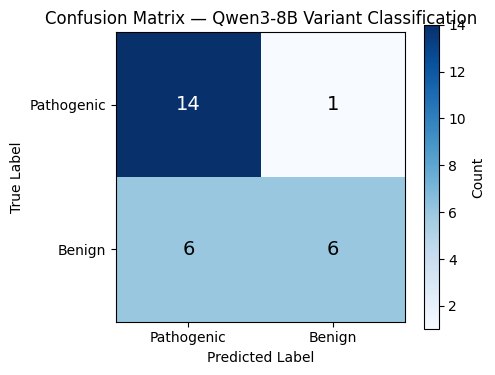

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred, labels=['Pathogenic', 'Benign'])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

labels = ['Pathogenic', 'Benign']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Qwen3-8B Variant Classification')

# Annotate each cell with its count
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

plt.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

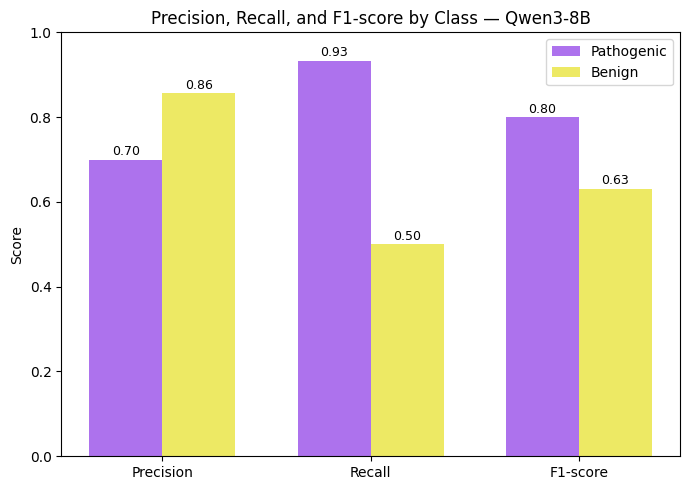

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=['Pathogenic', 'Benign']
)

metrics_names = ['Precision', 'Recall', 'F1-score']
pathogenic_scores = [precision[0], recall[0], f1[0]]
benign_scores = [precision[1], recall[1], f1[1]]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, pathogenic_scores, width, label='Pathogenic', color='#ad72ed')
bars2 = ax.bar(x + width/2, benign_scores, width, label='Benign', color='#ede964')

ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1-score by Class — Qwen3-8B')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.0)
ax.legend()

# Annotate bars with their values
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/metrics_comparison.png', dpi=150)
plt.show()